# MMLab | Phase 2 | Feature Engineering

From past experience I have noted that, sometimes the data is "pre-normalised" which causes problems later... This time making sure that this isn't the case 

In [13]:
import io
from typing import Iterable, Optional

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display

import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Draw



FINAL_DF = pd.read_csv("ALL_DATA/Final_File/QM9_main.csv")

FINAL_DF.info()

<class 'pandas.DataFrame'>
RangeIndex: 128294 entries, 0 to 128293
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   field1         128294 non-null  int64  
 1   unnamed:0      128294 non-null  int64  
 2   mol_id         128294 non-null  int64  
 3   smiles         128294 non-null  str    
 4   a              128294 non-null  float64
 5   b              128294 non-null  float64
 6   c              128294 non-null  float64
 7   mu             128294 non-null  float64
 8   alpha          128294 non-null  float64
 9   homo           128294 non-null  float64
 10  lumo           128294 non-null  float64
 11  gap            128294 non-null  float64
 12  r2             128294 non-null  float64
 13  zpve           128294 non-null  float64
 14  u0             128294 non-null  float64
 15  u298           128294 non-null  float64
 16  h298           128294 non-null  float64
 17  g298           128294 non-null  float64


In [14]:
# -----------------------------------------------------------------------------
# Function : mol_to_png_bytes
# Purpose  : Convert a SMILES string into PNG bytes for display in a widget.
# Inputs   : smiles (str), size (tuple[int, int])
# Output   : bytes | None
# Notes    : Returns None if the SMILES is missing or invalid.
# -----------------------------------------------------------------------------
def mol_to_png_bytes(
    smiles: Optional[str],
    size: tuple[int, int] = (360, 260)
) -> Optional[bytes]:
    if smiles is None or pd.isna(smiles) or str(smiles).strip() == "":
        return None

    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None

    img = Draw.MolToImage(mol, size=size)
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    return buf.getvalue()


# -----------------------------------------------------------------------------
# Function : _safe_text
# Purpose  : Build hover text safely from a row and a list of columns.
# Inputs   : row (pd.Series), cols (Iterable[str])
# Output   : str
# Notes    : Skips columns not present in the dataframe.
# -----------------------------------------------------------------------------
def _safe_text(row: pd.Series, cols: Iterable[str]) -> str:
    lines = []
    for col in cols:
        if col in row.index:
            lines.append(f"{col}: {row[col]}")
    return "<br>".join(lines)


# -----------------------------------------------------------------------------
# Function : make_interactive_molecule_dashboard
# Purpose  : Create a two-panel interactive scatter dashboard where clicking a
#            point updates a molecule panel and a metadata panel.
# Inputs   :
#            - df                : Source dataframe
#            - x1, y1            : Axes for left scatter
#            - x2, y2            : Axes for right scatter
#            - smiles_col        : Column holding SMILES strings
#            - id_col            : Optional identifier column shown in panel
#            - hover_cols        : Extra columns shown in hover text
#            - title             : Dashboard title
#            - point_size        : Scatter marker size
# Output   : widgets.VBox
# Notes    :
#            - Designed for Jupyter notebooks.
#            - Uses FigureWidget callbacks, so plotly + ipywidgets notebook
#              support is required.
#            - Selected point is drawn as a dedicated overlay trace added last,
#              so it stays on top.
# -----------------------------------------------------------------------------
def make_interactive_molecule_dashboard(
    df: pd.DataFrame,
    x1: str,
    y1: str,
    x2: str,
    y2: str,
    smiles_col: str = "smiles_reactant",
    id_col: Optional[str] = None,
    hover_cols: Optional[list[str]] = None,
    title: str = "Interactive Molecule Scatter Dashboard",
    point_size: int = 7,
    selected_size: int = 10,
    base_color: str = "rgba(70, 130, 180, 0.45)",
    base_border_color: str = "rgba(20, 20, 20, 0.65)",
    selected_color: str = "rgba(255, 60, 60, 1.0)",
    selected_border_color: str = "rgba(0, 0, 0, 1.0)",
) -> widgets.VBox:
    missing = [c for c in [x1, y1, x2, y2, smiles_col] if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    data = df.copy().reset_index(drop=True)
    hover_cols = hover_cols or []

    # -------------------------------------------------------------------------
    # Build hover text once so both panels stay consistent.
    # -------------------------------------------------------------------------
    hover_text = []
    for _, row in data.iterrows():
        base_cols = [id_col] if id_col else []
        base_cols += [x1, y1, x2, y2]
        base_cols += hover_cols
        hover_text.append(_safe_text(row, base_cols))

    # -------------------------------------------------------------------------
    # Base marker styling: uniform color, visible border.
    # -------------------------------------------------------------------------
    base_marker_dict = dict(
        size=point_size,
        color=base_color,
        line=dict(width=0.6, color=base_border_color),
        symbol="circle",
    )

    # -------------------------------------------------------------------------
    # Build figure
    # -------------------------------------------------------------------------
    fig = make_subplots(
        rows=1,
        cols=2,
        horizontal_spacing=0.08,
        subplot_titles=(f"{x1} vs {y1}", f"{x2} vs {y2}"),
    )

    # Base scatter traces
    fig.add_trace(
        go.Scattergl(
            x=data[x1],
            y=data[y1],
            mode="markers",
            marker=base_marker_dict,
            text=hover_text,
            hovertemplate="%{text}<extra></extra>",
            customdata=np.arange(len(data)),
            name="Left",
            showlegend=False,
        ),
        row=1,
        col=1,
    )

    fig.add_trace(
        go.Scattergl(
            x=data[x2],
            y=data[y2],
            mode="markers",
            marker=base_marker_dict,
            text=hover_text,
            hovertemplate="%{text}<extra></extra>",
            customdata=np.arange(len(data)),
            name="Right",
            showlegend=False,
        ),
        row=1,
        col=2,
    )

    # Selected-point overlays
    # Added LAST so they render on top.
    fig.add_trace(
        go.Scattergl(
            x=[],
            y=[],
            mode="markers",
            marker=dict(
                size=selected_size,
                color=selected_color,
                line=dict(width=1.2, color=selected_border_color),
                symbol="circle",
            ),
            hoverinfo="skip",
            showlegend=False,
            name="Selected Left",
        ),
        row=1,
        col=1,
    )

    fig.add_trace(
        go.Scattergl(
            x=[],
            y=[],
            mode="markers",
            marker=dict(
                size=selected_size,
                color=selected_color,
                line=dict(width=1.2, color=selected_border_color),
                symbol="circle",
            ),
            hoverinfo="skip",
            showlegend=False,
            name="Selected Right",
        ),
        row=1,
        col=2,
    )

    fig.update_layout(
        title=dict(text=title, x=0.5),
        template="plotly_white",
        width=1200,
        height=560,
        margin=dict(l=40, r=20, t=80, b=40),
        dragmode="select",
    )

    fig.update_xaxes(
        showline=True,
        linewidth=1,
        linecolor="black",
        mirror=True,
        gridcolor="rgba(0,0,0,0.08)",
        zeroline=False,
    )
    fig.update_yaxes(
        showline=True,
        linewidth=1,
        linecolor="black",
        mirror=True,
        gridcolor="rgba(0,0,0,0.08)",
        zeroline=False,
    )

    fw = go.FigureWidget(fig)

    # Selected overlay trace indices
    highlight_left_idx = 2
    highlight_right_idx = 3

    # -------------------------------------------------------------------------
    # Right-side information panel
    # -------------------------------------------------------------------------
    mol_img = widgets.Image(layout=widgets.Layout(width="380px", height="280px"))
    header_html = widgets.HTML("<b>Selected molecule</b>")
    info_html = widgets.HTML("Click a point in either scatter plot.")

    # -------------------------------------------------------------------------
    # Function : update_selection
    # Purpose  : Update molecule panel + selected-point overlays from row index.
    # -------------------------------------------------------------------------
    def update_selection(idx: int) -> None:
        row = data.iloc[idx]

        png = mol_to_png_bytes(row[smiles_col])
        mol_img.value = png if png is not None else b""

        info_rows = []
        if id_col and id_col in data.columns:
            info_rows.append(f"<b>{id_col}</b>: {row[id_col]}")

        info_rows += [
            f"<b>{x1}</b>: {row[x1]}",
            f"<b>{y1}</b>: {row[y1]}",
            f"<b>{x2}</b>: {row[x2]}",
            f"<b>{y2}</b>: {row[y2]}",
        ]

        seen = {x1, y1, x2, y2, id_col}
        for col in hover_cols:
            if col in data.columns and col not in seen:
                info_rows.append(f"<b>{col}</b>: {row[col]}")

        if smiles_col in data.columns:
            info_rows.append(f"<b>{smiles_col}</b>: <code>{row[smiles_col]}</code>")

        info_html.value = "<br>".join(info_rows)

        with fw.batch_update():
            # Put selected point on top in left plot
            fw.data[highlight_left_idx].x = [row[x1]]
            fw.data[highlight_left_idx].y = [row[y1]]

            # Put selected point on top in right plot
            fw.data[highlight_right_idx].x = [row[x2]]
            fw.data[highlight_right_idx].y = [row[y2]]

    # -------------------------------------------------------------------------
    # Shared click callback
    # -------------------------------------------------------------------------
    def _handle_click(trace, points, selector):
        if not points.point_inds:
            return
        idx = int(points.point_inds[0])
        update_selection(idx)

    fw.data[0].on_click(_handle_click)
    fw.data[1].on_click(_handle_click)

    # Initialise with first row
    if len(data) > 0:
        update_selection(0)

    # -------------------------------------------------------------------------
    # Layout
    # -------------------------------------------------------------------------
    side_panel = widgets.VBox(
        [header_html, mol_img, info_html],
        layout=widgets.Layout(width="400px", padding="10px 0 0 10px"),
    )

    dashboard = widgets.HBox(
        [fw, side_panel],
        layout=widgets.Layout(align_items="flex-start"),
    )

    return widgets.VBox([dashboard])


# -----------------------------------------------------------------------------
# Example usage
# -----------------------------------------------------------------------------
ui = make_interactive_molecule_dashboard(
    df=FINAL_DF,
    x1="gini_n",
    y1="max",
    x2="gini_p",
    y2="max",
    smiles_col="smiles",
    id_col="mol_id",
    hover_cols=["max", "min", "gini_p", "gini_n"],
    title="Interactive Two-Panel Molecule Dashboard",
)

display(ui)

    'data': [{'customdata': {'bdata': ('AAAAAAEAAAACAAAAAwAAAAQAA…

# hmmmmm...

# Pairwise plots

In [18]:
def pairplot_matplotlib(
    df,
    cols,
    bins=30,
    figsize=(10, 10),
    point_size=6,
    alpha=0.4,
):
    n = len(cols)

    fig, axes = plt.subplots(n, n, figsize=figsize)

    for i in range(n):
        for j in range(n):
            ax = axes[i, j]

            x = df[cols[j]]
            y = df[cols[i]]

            # -------------------------------------------------------------
            # Diagonal → histogram
            # -------------------------------------------------------------
            if i == j:
                ax.hist(x, bins=bins, color="steelblue", alpha=0.8)
            
            # -------------------------------------------------------------
            # Off-diagonal → scatter
            # -------------------------------------------------------------
            else:
                ax.scatter(
                    x,
                    y,
                    s=point_size,
                    alpha=alpha,
                    color="steelblue",
                    edgecolors="black",
                    linewidths=0.2,
                )

            # -------------------------------------------------------------
            # Clean axes
            # -------------------------------------------------------------
            if i < n - 1:
                ax.set_xticklabels([])
            else:
                ax.set_xlabel(cols[j])

            if j > 0:
                ax.set_yticklabels([])
            else:
                ax.set_ylabel(cols[i])

    plt.tight_layout()
    plt.show()

    return fig

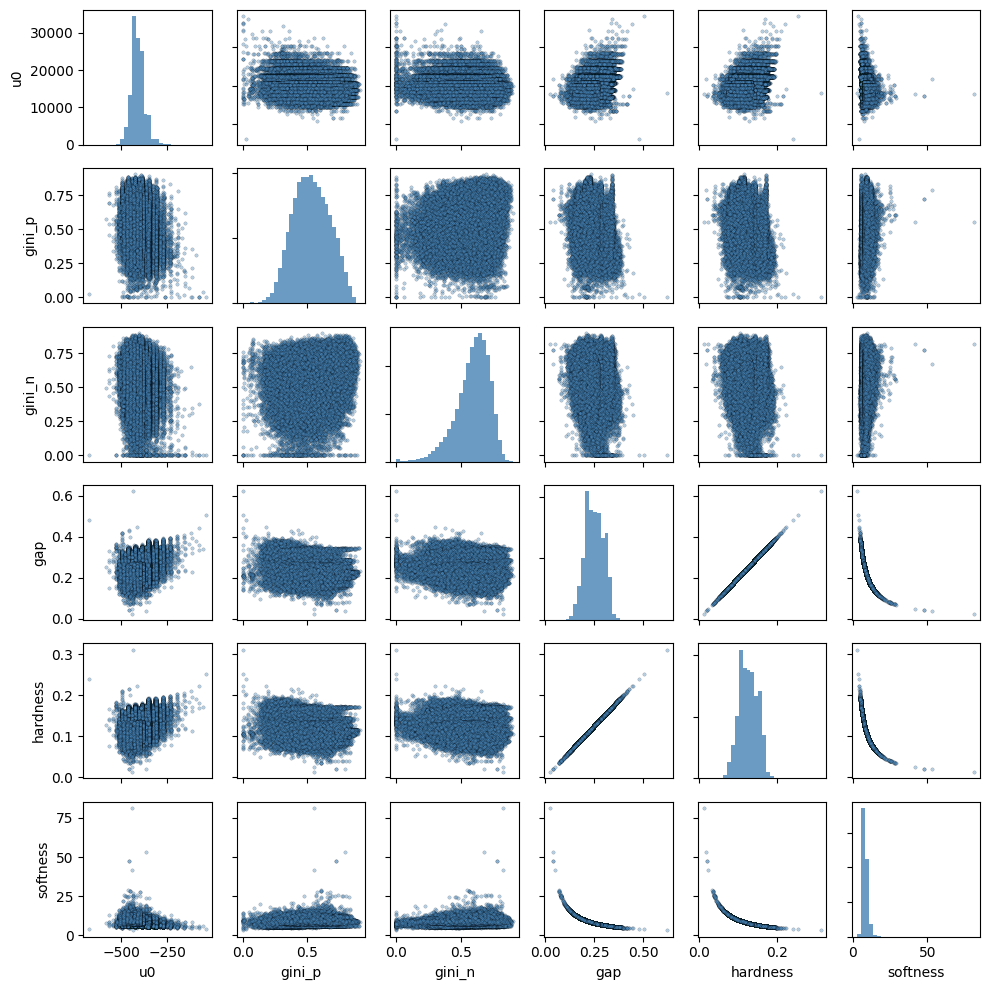

In [ ]:
cols = [
    "u0",
    "gini_p",
    "gini_n",
    "gap",
    "hardness",
    "softness",
]

a = pairplot_matplotlib(FINAL_DF, cols)
# a.savefig("Images/All_in_ONE_Plots/All_in_ONE_Plot.png", dpi=1200)